Predicting The New York Times Critic's Picks Using Machine Learning, Text Analysis and Review Metadata

#### Maxfield Raynolds
#### Data 620
#### Spring 2026

New York Times “Critics’ Picks” are often used as indicators of critical acclaim and are frequently leveraged in film marketing. This paper investigates whether machine learning models can predict a film’s “Critics’ Pick” designation using review text, metadata, and network-based features derived from associated film personnel.

Data were collected using The New York Times API and processed to construct a dataset of movie reviews and associated metadata. A bipartite network of films and their top-billed actors and directors was constructed, and centrality measures were computed from projections of this network. Aggregated centrality features were generated at the film level using actor and director centrality statistics.

Textual features were extracted from review lead paragraphs using TF-IDF and VADER sentiment analysis. Additional metadata features, including byline information, were encoded using OneHotEncoder.

A series of classification models were trained to predict the “Critics’ Pick” label, including logistic regression and support vector machines. Recursive feature elimination was applied to evaluate feature importance across the full feature set. Among all models tested, a simple logistic regression model using only lead paragraph word count achieved the strongest performance, outperforming models incorporating richer feature sets.

These results suggest that, for this dataset, simple textual length-based features are more predictive of “Critics’ Pick” status than more complex textual, metadata, or network-derived features.

### Data Acquistion

Import packages

In [1]:
import requests
import pandas as pd
import networkx as nx
import os
import numpy as np
import time

from narwhals import read_parquet
from networkx.algorithms import bipartite as bi


The following code recalls the API key and loads it into the environment.

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("NYT_API_KEY")

The following code queries The New York Times' Article Search API to retrieve metadata about movie reviews from 2020 through 2025.

In [3]:
import requests
import time
from datetime import datetime

start_year = [2020, 2021, 2022, 2023, 2024, 2025]
end_year = [year + 1 for year in start_year]
day_month = '0101'
all_docs = []

def make_request_with_retry(url, max_retries=3):
    for attempt in range(max_retries):
        r = requests.get(url)

        if r.status_code == 200:
            return r
        elif r.status_code == 429:
            wait_time = (2 ** attempt) * 60  # 60s, 120s, 240s
            print(f'Rate limited. Waiting {wait_time}s before retry {attempt + 1}/{max_retries}')
            time.sleep(wait_time)
        else:
            print(f'Error {r.status_code}')
            return None

    return None

for start, end in zip(start_year, end_year):
    for page in range(0, 100):
        url = f'https://api.nytimes.com/svc/search/v2/articlesearch.json?&fq=typeOfMaterials%3AReview AND section.name%3AMovies&begin_date={start}{day_month}&end_date={end}{day_month}&page={page}&api-key={api_key}'

        print(f'Fetching year {start}, page {page}...')
        r = make_request_with_retry(url)

        if r is None:
            print(f'Failed after retries. Stopping at page {page}')
            break

        data = r.json()
        docs = data['response']['docs']

        if not docs:
            print(f'No more docs at page {page}')
            break

        all_docs.extend(docs)
        print(f'Got {len(docs)} docs (total: {len(all_docs)})')

        time.sleep(12)

print(f'Total documents collected: {len(all_docs)}')

Fetching year 2020, page 0...
Got 10 docs (total: 10)
Fetching year 2020, page 1...
Got 10 docs (total: 20)
Fetching year 2020, page 2...
Got 10 docs (total: 30)
Fetching year 2020, page 3...
Got 10 docs (total: 40)
Fetching year 2020, page 4...
Got 10 docs (total: 50)
Fetching year 2020, page 5...
Got 10 docs (total: 60)
Fetching year 2020, page 6...
Got 10 docs (total: 70)
Fetching year 2020, page 7...
Got 10 docs (total: 80)
Fetching year 2020, page 8...
Got 10 docs (total: 90)
Fetching year 2020, page 9...
Got 10 docs (total: 100)
Fetching year 2020, page 10...
Got 10 docs (total: 110)
Fetching year 2020, page 11...
Got 10 docs (total: 120)
Fetching year 2020, page 12...
Got 10 docs (total: 130)
Fetching year 2020, page 13...
Got 10 docs (total: 140)
Fetching year 2020, page 14...
Got 10 docs (total: 150)
Fetching year 2020, page 15...
Got 10 docs (total: 160)
Fetching year 2020, page 16...
Got 10 docs (total: 170)
Fetching year 2020, page 17...
Got 10 docs (total: 180)
Fetching ye

The following code downloads additional information about movie reviews using The New York Times' Archive Search API.

In [4]:
import requests
import time
from datetime import datetime

api_key = os.getenv("NYT_API_KEY")
all_movie_reviews = []

# Get all months for 2020-2021
years = [2020, 2021, 2022, 2023, 2024, 2025]
months = range(1, 13)  # 1-12

for year in years:
    for month in months:
        print(f'Fetching {year}-{month:02d}...')

        url = f'https://api.nytimes.com/svc/archive/v1/{year}/{month}.json?api-key={api_key}'

        try:
            r = requests.get(url)

            if r.status_code == 200:
                data = r.json()
                all_articles = data['response']['docs']

                # Filter for movie reviews
                movie_reviews = [
                    doc for doc in all_articles
                    if doc.get('section_name') == 'Movies'
                       and doc.get('type_of_material') == 'Review'
                ]

                all_movie_reviews.extend(movie_reviews)
                print(f'  Found {len(movie_reviews)} reviews (total: {len(all_movie_reviews)})')

            elif r.status_code == 429:
                print(f'  Rate limited. Waiting 60s...')
                time.sleep(60)
                continue  # Retry this month

            else:
                print(f'  Error {r.status_code}')

        except Exception as e:
            print(f'  Exception: {e}')

        # Archive API: 10 requests/minute max
        time.sleep(6)  # Safe: 10 per minute

print(f'\nTotal movie reviews collected: {len(all_movie_reviews)}')

# Save to file
import json

with open('nyt_movie_reviews.json', 'w') as f:
    json.dump(all_movie_reviews, f, indent=2)

Fetching 2020-01...
  Found 41 reviews (total: 41)
Fetching 2020-02...
  Found 52 reviews (total: 93)
Fetching 2020-03...
  Found 41 reviews (total: 134)
Fetching 2020-04...
  Found 51 reviews (total: 185)
Fetching 2020-05...
  Found 51 reviews (total: 236)
Fetching 2020-06...
  Rate limited. Waiting 60s...
Fetching 2020-07...
  Found 60 reviews (total: 296)
Fetching 2020-08...
  Found 57 reviews (total: 353)
Fetching 2020-09...
  Found 61 reviews (total: 414)
Fetching 2020-10...
  Found 66 reviews (total: 480)
Fetching 2020-11...
  Found 60 reviews (total: 540)
Fetching 2020-12...
  Found 55 reviews (total: 595)
Fetching 2021-01...
  Found 48 reviews (total: 643)
Fetching 2021-02...
  Found 55 reviews (total: 698)
Fetching 2021-03...
  Rate limited. Waiting 60s...
Fetching 2021-04...
  Found 62 reviews (total: 760)
Fetching 2021-05...
  Found 54 reviews (total: 814)
Fetching 2021-06...
  Found 70 reviews (total: 884)
Fetching 2021-07...
  Found 80 reviews (total: 964)
Fetching 2021-08

The API query is returned from the API as json. The code below converts both sets of retrieved data into pandas dataframes.

In [5]:
article_search = pd.json_normalize(all_docs)
archive_search = pd.json_normalize(all_movie_reviews)

Here is a look at the columns included with the article_search API call.

In [6]:
article_search.columns

Index(['abstract', 'document_type', '_id', 'keywords', 'news_desk',
       'print_page', 'print_section', 'pub_date', 'section_name', 'snippet',
       'source', 'subsection_name', 'type_of_material', 'uri', 'web_url',
       'word_count', 'byline.original', 'headline.main', 'headline.kicker',
       'headline.print_headline', 'multimedia.caption', 'multimedia.credit',
       'multimedia.default.url', 'multimedia.default.height',
       'multimedia.default.width', 'multimedia.thumbnail.url',
       'multimedia.thumbnail.height', 'multimedia.thumbnail.width'],
      dtype='str')

The id column name is changed in order to start the process of cleaning and merging the two set of data.

In [7]:
article_search.rename(columns = {
    '_id':'id'
}, inplace = True)

A list of the shared columns of the two dataframes is made and then the archive search is made into a subset so that there will be no repeated columns when the two dataframes are merged.

In [8]:
shared_columns = list(set(article_search.columns) & set(archive_search.columns))
archive_search_subset = archive_search.drop(columns = shared_columns)

The two dataframes are then merged, the duplicated 'id' column is dropped, and the columns are renamed.

In [9]:
df = article_search.merge(archive_search_subset, left_on='id', right_on='_id', how='left')

In [10]:
df.drop(columns = ['_id'], inplace = True)

In [11]:
df.rename(columns = {
    'byline.original':'byline_original',
    'headline.main':'headline_main',
    'headline.kicker':'headline_kicker',
    'headline.print_headline':'headline_print_headline',
    'multimedia.caption':'multimedia_caption',
    'multimedia.credit':'multimedia_credit',
    'multimedia.default.url':'multimedia_default_url',
    'multimedia.default.height':'multimedia_default_height',
    'multimedia.default.width':'multimedia_default_width',
    'multimedia.thumbnail.url':'multimedia_thumbnail_url',
    'multimedia.thumbnail.height':'multimedia_thumbnail_height',
    'multimedia.thumbnail.width':'multimedia_thumbnail_width',
    'headline.name':'headline_name',
    'headline.seo':'headline_seo',
    'byline.person':'byline_person',
    'byline.organization':'byline_organization',
    'headline.sub':'headline_sub'
}, inplace = True)

The film titles are extracted from the headlines.

In [12]:
df['film_title'] = df['headline_main'].str.extract(r'[\u2018\u2019]([^\u2018\u2019]*?)[\u2018\u2019]')

All columns that are entirely comprised on NA values are dropped, and rows with any values are dropped.

In [13]:
df.dropna(axis=1, how='all', inplace=True)
df = df.dropna(axis = 0, how = 'any')

The cleaned and merged data frame is saved to a parquet file.

In [14]:
# df.to_parquet("nyt_film_review_list_raw.parquet")

In [15]:
df = pd.read_parquet("nyt_film_review_list_raw.parquet")

### Preparing the data for network creation

#### Building the edge list

Currently, information about the director and top billed actors is stored as a list of dictionaries in the 'keyword' column. The creates a dataframe that explodes those dictionaries so each keyword has its own row, while retaining their id number for later merging.

In [16]:
df_keys = df[['id', 'keywords']].explode('keywords')

df_keys = pd.concat(
    [
        df_keys.drop(columns=['keywords']),
        df_keys['keywords'].apply(pd.Series)
    ],
    axis = 1
)

The keywords included several types of values. This analysis will only use the 'Person' type; the other types were filtered out of the dataframe.

In [17]:
df_keys['name'].unique()

<ArrowStringArray>
['Subject', 'Person', 'Title', 'Location', 'Organization', 'Keyword', '']
Length: 7, dtype: str

In [18]:
people = df_keys[df_keys['name'] == 'Person'].drop(columns = ['rank', 'name']).rename(columns = {'value':'person_name'})

The code below cleans up the information about the people, some names are listed with birth years or other information. The code below separates this data out and rearranges the perople's names so they are in a "First Name Last Name" order.

In [19]:
split_result = people['person_name'].str.split('(', n=1, expand=True)
people['person_name'] = split_result[0]
people['fact'] = split_result[1].fillna('') if 1 in split_result.columns else ''
people['birth_year'] = pd.to_numeric(people['fact'], errors='coerce')
people['fact'] = people['fact'].str.replace(r'[^\w\s]','',regex=True)
people['birth_year'] = pd.to_numeric(people['fact'], errors='coerce')
people['position'] = people['fact'].where(people['birth_year'].isna())
people.drop(columns=['fact'], inplace=True)
people[['last_name','first_name']] = people['person_name'].str.split(', ', expand=True)
people['first_name'] = people['first_name'].str.strip()
people['last_name'] = people['last_name'].str.strip()
people['person_name'] = people['first_name'].str.cat(people['last_name'], sep = ' ', na_rep='')
people.drop(columns=['first_name', 'last_name'], inplace=True)

With the list of people created, the code below creates a list of just the review id's and film titles.

In [20]:
films = df[['id','film_title']]

In [21]:
people.head(5)

,id,person_name,birth_year,position
0,nyt://article/ecccf741-688e-5f99-8081-dbd57d10...,Tanna Frederick,NaN,
0,nyt://article/ecccf741-688e-5f99-8081-dbd57d10...,Ron Vignone,NaN,
1,nyt://article/31a59fdb-464b-52ae-8898-afa2dbf6...,Roseanne Liang,NaN,
1,nyt://article/31a59fdb-464b-52ae-8898-afa2dbf6...,Chloe Grace Moretz,NaN,
2,nyt://article/a7081670-a6d3-5e5e-b7bb-a50e47c0...,Alexandre Franchi,NaN,


In [22]:
films.head(5)

,id,film_title
0,nyt://article/ecccf741-688e-5f99-8081-dbd57d10...,Two Ways Home
1,nyt://article/31a59fdb-464b-52ae-8898-afa2dbf6...,Shadow in the Cloud
2,nyt://article/a7081670-a6d3-5e5e-b7bb-a50e47c0...,Happy Face
3,nyt://article/6c985343-e4ad-537e-b568-37a8ad50...,Pieces of a Woman
4,nyt://article/412cf660-b57a-5965-8890-e4cdfa41...,Night of the Kings


The list of films and people are merged to create an edge list for network construction.

In [23]:
edges = pd.merge(films, people, on='id', how='inner')

In [24]:
features = df[['id', 'film_title', 'abstract', 'lead_paragraph', 'pub_date', 'word_count', 'byline_original', 'headline_main', 'headline_kicker', 'headline_print_headline', 'multimedia_caption', 'multimedia_credit']]

In [25]:
edges

,id,film_title,person_name,birth_year,position
0,nyt://article/ecccf741-688e-5f99-8081-dbd57d10...,Two Ways Home,Tanna Frederick,NaN,
1,nyt://article/ecccf741-688e-5f99-8081-dbd57d10...,Two Ways Home,Ron Vignone,NaN,
2,nyt://article/31a59fdb-464b-52ae-8898-afa2dbf6...,Shadow in the Cloud,Roseanne Liang,NaN,
3,nyt://article/31a59fdb-464b-52ae-8898-afa2dbf6...,Shadow in the Cloud,Chloe Grace Moretz,NaN,
4,nyt://article/a7081670-a6d3-5e5e-b7bb-a50e47c0...,Happy Face,Alexandre Franchi,NaN,
...,...,...,...,...,...
6721,nyt://article/a3beac42-7658-5b37-8d21-619be132...,Memory,Elsie Fisher,2003.0,NaN
6722,nyt://article/a94ca759-7f49-5676-973b-b6ab4ee5...,Good Grief,Daniel Levy,NaN,Actor
6723,nyt://article/a94ca759-7f49-5676-973b-b6ab4ee5...,Good Grief,Ruth Negga,1982.0,NaN
6724,nyt://article/a94ca759-7f49-5676-973b-b6ab4ee5...,Good Grief,Himesh Patel,NaN,


In [46]:
nodes = pd.DataFrame(pd.concat([pd.Series(edges['id'].unique()), pd.Series(edges['person_name'].unique())], axis=0).reset_index(drop=True)).rename(columns = {0:'node'})

film_nodes = pd.DataFrame({'node':edges['id'].unique()})
people_nodes = pd.DataFrame({'node':edges['person_name'].unique()})

In [27]:
attributes = features[['id', 'film_title', 'headline_kicker', 'word_count']]

### Create the Network

Below is a look at the number of edges that will be used to construct the full network.

In [28]:
edges.count()

id             6726
film_title     6726
person_name    6726
birth_year      955
position       5771
dtype: int64

In [29]:
nodes.count()

node    8026
dtype: int64

The full network is constructed.

In [30]:
G = nx.from_pandas_edgelist(edges, 'id', 'person_name')
for n in edges['id'].unique():
    G.nodes[n]['bipartite'] = 0
for n in edges['person_name'].unique():
    G.nodes[n]['bipartite'] = 1
bi.is_bipartite(G)

True

In [31]:
node_attribute_dict = attributes.set_index('id').to_dict('index')
nx.set_node_attributes(G, node_attribute_dict)

Below are some attributes of the full constructed network, and its largest connected component.

In [32]:
print(len(G.nodes),"nodes")
print(len(G.edges),"edges")
print('Number of connected components: ', nx.number_connected_components(G))
largest_cc = max(nx.connected_components(G), key=len)
L = G.subgraph(largest_cc).copy()
print(len(L.nodes), ' nodes in the largest connected component')
print(len(L.edges), ' edges in the largest connected component')
print("Largest Connected Component Diameter:", nx.diameter(L))

8026 nodes
6726 edges
Number of connected components:  1611
3059  nodes in the largest connected component
3354  edges in the largest connected component
Largest Connected Component Diameter: 31


Considering the large number of connected components,the largest connected component will be considered as the starting point for the remaining analysis in this paper.

### Centrality Measures

#### People Centrality

In [48]:
film_proj = bi.projected_graph(L, [n for n in film_nodes['node'] if n in L])
people_proj = bi.projected_graph(L, [n for n in people_nodes['node'] if n in L])

In [49]:
def sorted_map(G):
    G_dict = dict(G)

    ms = sorted(G_dict.items(), key=lambda item: (-item[1], item[0]))
    return ms

Looking at the top central figures by degree the highest degree is Willem Dafoe, a long working character actor who appears in many films including ones with large ensemble casts and often with leading actors who might be considered more famous than him. Overall the list includes many similar people, often long working actors, of notable fame and who work frequently and often with large ensembles.

In [52]:
d = dict(people_proj.degree())
sorted_map(d)[:15]

[('Willem Dafoe', 33),
 ('Samuel L Jackson', 28),
 ('Chris Pine', 22),
 ('Adam Sandler', 21),
 ('Nora Lum', 21),
 ('Tiffany Haddish', 21),
 ('Danny DeVito', 20),
 ('John David Washington', 20),
 ('Mark Wahlberg', 20),
 ('Tom Holland', 20),
 ('Viola Davis', 20),
 ('Ben Affleck', 19),
 ('Denzel Washington', 19),
 ('Donald J Trump', 19),
 ('Idris Elba', 19)]

The remaining centrality lists consist of many of the same names as the degree list.

In [53]:
dc = nx.degree_centrality(people_proj)
sorted_map(dc)[:15]

[('Willem Dafoe', 0.016717325227963528),
 ('Samuel L Jackson', 0.014184397163120569),
 ('Chris Pine', 0.011144883485309018),
 ('Adam Sandler', 0.010638297872340427),
 ('Nora Lum', 0.010638297872340427),
 ('Tiffany Haddish', 0.010638297872340427),
 ('Danny DeVito', 0.010131712259371834),
 ('John David Washington', 0.010131712259371834),
 ('Mark Wahlberg', 0.010131712259371834),
 ('Tom Holland', 0.010131712259371834),
 ('Viola Davis', 0.010131712259371834),
 ('Ben Affleck', 0.009625126646403243),
 ('Denzel Washington', 0.009625126646403243),
 ('Donald J Trump', 0.009625126646403243),
 ('Idris Elba', 0.009625126646403243)]

In [54]:
cc = nx.closeness_centrality(people_proj)
sorted_map(cc)[:15]

[('Willem Dafoe', 0.2235813795446823),
 ('Tom Holland', 0.22307605379138887),
 ('John David Washington', 0.2224726698974417),
 ('Zendaya Coleman', 0.21935770641182353),
 ('Danny DeVito', 0.21694691724365314),
 ('Samuel L Jackson', 0.21642363775901766),
 ('Denzel Washington', 0.21505610632966554),
 ('Ben Affleck', 0.2149390243902439),
 ('Matt Damon', 0.21368261528469365),
 ('Viola Davis', 0.21285313780461504),
 ('Chris Pine', 0.2120984205436768),
 ('Pedro Pascal', 0.21112299465240641),
 ('Nora Lum', 0.21040289916862076),
 ('Ridley Scott', 0.210111761575306),
 ('Jennifer Jason Leigh', 0.20993300010634905)]

In [55]:
bc = nx.betweenness_centrality(people_proj)
sorted_map(bc)[:15]

[('Willem Dafoe', 0.10087141001963332),
 ('Tom Holland', 0.08530403941617724),
 ('Mark Wahlberg', 0.06389191392003801),
 ('Chris Pine', 0.06351436501756888),
 ('Danny DeVito', 0.057130847258542616),
 ('John David Washington', 0.05556966257765981),
 ('Zendaya Coleman', 0.0544199098807404),
 ('Samuel L Jackson', 0.054196500071539325),
 ('Mia Wasikowska', 0.05157320708385465),
 ('Vicky Krieps', 0.04716739112559443),
 ('Viola Davis', 0.04548745224956022),
 ('Nora Lum', 0.04388918941180691),
 ('Jeremy Strong', 0.04365341554238297),
 ('Jennifer Jason Leigh', 0.04130955315833345),
 ('Ben Affleck', 0.04122422817050296)]

Eignevector centrality has the most unique names, especially considering many of these performers do not work professionally anymore, and several of whom are dead. Many of their appearances on this list are related to documentaries.

In [56]:
ec = nx.eigenvector_centrality(people_proj)
sorted_map(ec)[:15]

[('Willem Dafoe', 0.385396863210187),
 ('Rachel Sennott', 0.284852009361299),
 ('Dan Aykroyd', 0.2801867957246368),
 ('Cooper Hoffman', 0.2648720882711573),
 ('Jason Reitman', 0.2648720882711573),
 ('John Belushi', 0.26233948593732187),
 ('Chevy Chase', 0.2602015474239292),
 ('George Carlin', 0.2602015474239292),
 ('Gilda Radner', 0.2602015474239292),
 ('Matthew Rhys', 0.2602015474239292),
 ('Nicholas Braun', 0.2602015474239292),
 ('Jenna Ortega', 0.10183008297526432),
 ('Michael Keaton', 0.09115722643434629),
 ('Justin Theroux', 0.0899573960722254),
 ('Monica Bellucci', 0.08907814416394608)]

In [57]:
pr = nx.pagerank(people_proj)
sorted_map(pr)[:15]

[('Willem Dafoe', 0.002547195054111263),
 ('Samuel L Jackson', 0.0022197086223591372),
 ('Mark Wahlberg', 0.0021567565499638623),
 ('Adam Sandler', 0.0021457768905892363),
 ('Donald J Trump', 0.002135570051158924),
 ('Chris Pine', 0.0020605738315307206),
 ('Liam Neeson', 0.002012900083106998),
 ('Idris Elba', 0.0018815206497543246),
 ('Joey King', 0.0018658348328330647),
 ('Peter Sarsgaard', 0.0017892895351564026),
 ('Juliette Binoche', 0.0017837422677400246),
 ('Nicolas Cage', 0.0017740276850009714),
 ('Tiffany Haddish', 0.0017691629241265532),
 ('Nora Lum', 0.001758961647149007),
 ('Ben Affleck', 0.001751169997250075)]

In [58]:
people_comparison = pd.DataFrame({
    'name': list(people_proj.nodes),
    'degree': [d[n] for n in people_proj.nodes()],
    'degree_centrality': [dc[n] for n in people_proj.nodes()],
    'closeness_centrality': [cc[n] for n in people_proj.nodes()],
    'betweenness': [bc[n] for n in people_proj.nodes()],
    'eigenvector': [ec[n] for n in people_proj.nodes()],
    'pagerank': [pr[n] for n in people_proj.nodes()]
})

people_comparison.sort_values('degree', ascending = False)[:15]

,name,degree,degree_centrality,closeness_centrality,betweenness,eigenvector,pagerank
511,Willem Dafoe,33,0.016717,0.223581,0.100871,0.385397,0.002547
475,Samuel L Jackson,28,0.014184,0.216424,0.054197,0.010743,0.002220
9,Chris Pine,22,0.011145,0.212098,0.063514,0.004694,0.002061
1441,Nora Lum,21,0.010638,0.210403,0.043889,0.019046,0.001759
558,Tiffany Haddish,21,0.010638,0.204411,0.030572,0.005960,0.001769
179,Adam Sandler,21,0.010638,0.154339,0.021169,0.000152,0.002146
23,Viola Davis,20,0.010132,0.212853,0.045487,0.018539,0.001686
462,Mark Wahlberg,20,0.010132,0.205176,0.063892,0.009501,0.002157
243,Tom Holland,20,0.010132,0.223076,0.085304,0.071171,0.001675
279,John David Washington,20,0.010132,0.222473,0.055570,0.017748,0.001658


#### Reconsider centrality without leaf nodes

As the table below shows, there are more than 200 people who are leaf nodes and are connected to only one film. How does there elimination effect the graph as a whole and how does it change centrality?

In [59]:
people_comparison[people_comparison['degree'] == 1]

,name,degree,degree_centrality,closeness_centrality,betweenness,eigenvector,pagerank
0,Roseanne Liang,1,0.000507,0.114701,0.0,8.641750e-07,0.000210
6,Kone Bakary,1,0.000507,0.138023,0.0,1.979029e-04,0.000174
22,Paul Dugdale,1,0.000507,0.120963,0.0,5.828267e-06,0.000210
34,Barry Gibb,1,0.000507,0.116453,0.0,6.097239e-07,0.000267
79,Frank Zappa,1,0.000507,0.116275,0.0,1.957357e-06,0.000211
...,...,...,...,...,...,...,...
1955,Gonzalo Lopez-Gallego,1,0.000507,0.121777,0.0,4.298038e-06,0.000166
1956,Charles III Stone,1,0.000507,0.135428,0.0,2.132358e-05,0.000174
1957,Rachel Lambert,1,0.000507,0.162376,0.0,8.047515e-04,0.000170
1960,Mahalia Belo,1,0.000507,0.172266,0.0,1.227570e-03,0.000156


The graph has leaf nodes elminated, creating a core network.

In [60]:
L_core = nx.k_core(L, k=2)

In [61]:
film_core = {n for n,d in L_core.nodes(data=True) if d.get('bipartite') == 0}
people_core = set(L_core) - film_core

In [62]:
film_proj_core = bi.projected_graph(L_core, film_core)
people_proj_core = bi.projected_graph(L_core, people_core)

In [63]:
d_core = dict(people_proj_core.degree())
sorted_map(d_core)[:15]

[('Willem Dafoe', 16),
 ('Danny DeVito', 14),
 ('Samuel L Jackson', 13),
 ('Tom Holland', 13),
 ('Viola Davis', 13),
 ('Anthony Mackie', 12),
 ('Idris Elba', 12),
 ('Matt Damon', 12),
 ('Ridley Scott', 12),
 ('Aubrey Plaza', 11),
 ('Jenna Ortega', 11),
 ('John David Washington', 11),
 ('Mia Wasikowska', 11),
 ('Pedro Pascal', 11),
 ('Tiffany Haddish', 11)]

In [64]:
dc_core = nx.degree_centrality(people_proj_core)
sorted_map(dc_core)[:15]

[('Willem Dafoe', 0.032),
 ('Danny DeVito', 0.028),
 ('Samuel L Jackson', 0.026000000000000002),
 ('Tom Holland', 0.026000000000000002),
 ('Viola Davis', 0.026000000000000002),
 ('Anthony Mackie', 0.024),
 ('Idris Elba', 0.024),
 ('Matt Damon', 0.024),
 ('Ridley Scott', 0.024),
 ('Aubrey Plaza', 0.022),
 ('Jenna Ortega', 0.022),
 ('John David Washington', 0.022),
 ('Mia Wasikowska', 0.022),
 ('Pedro Pascal', 0.022),
 ('Tiffany Haddish', 0.022)]

In [65]:
cc_core = nx.closeness_centrality(people_proj_core)
sorted_map(cc_core)[:15]

[('Willem Dafoe', 0.26737967914438504),
 ('Tom Holland', 0.26666666666666666),
 ('John David Washington', 0.2648305084745763),
 ('Zendaya Coleman', 0.26109660574412535),
 ('Samuel L Jackson', 0.2564102564102564),
 ('Danny DeVito', 0.2556237218813906),
 ('Denzel Washington', 0.25380710659898476),
 ('Ben Affleck', 0.25342118601115055),
 ('Matt Damon', 0.2502502502502503),
 ('Viola Davis', 0.249500998003992),
 ('Chris Pine', 0.2485089463220676),
 ('Ridley Scott', 0.24752475247524752),
 ('Pedro Pascal', 0.2455795677799607),
 ('Jennifer Jason Leigh', 0.24545900834560627),
 ('Jodie Comer', 0.24533856722276742)]

In [66]:
bc_core = nx.betweenness_centrality(people_proj_core)
sorted_map(bc_core)[:15]

[('Willem Dafoe', 0.09163525776860358),
 ('Tom Holland', 0.08908923632958098),
 ('Mark Wahlberg', 0.06050877872065557),
 ('Zendaya Coleman', 0.05755205586272934),
 ('Danny DeVito', 0.0551769738788932),
 ('Mia Wasikowska', 0.05065199118011149),
 ('Samuel L Jackson', 0.0505392852638908),
 ('Chris Pine', 0.050191483876006346),
 ('John David Washington', 0.04961352947935667),
 ('Nora Lum', 0.040062593963415244),
 ('Viola Davis', 0.03502407303056453),
 ('Jennifer Jason Leigh', 0.03451846752296736),
 ('Nicole Kidman', 0.03448792015659438),
 ('Joey King', 0.034164081340359635),
 ('Idris Elba', 0.0337700467213565)]

In [67]:
ec_core = nx.eigenvector_centrality(people_proj_core)
sorted_map(ec_core)[:15]

[('Matt Damon', 0.2529373562787834),
 ('Pedro Pascal', 0.23490828168909758),
 ('Ridley Scott', 0.20575107751515773),
 ('Viola Davis', 0.1892702765952844),
 ('Geraldine Viswanathan', 0.17280674692318124),
 ('Denzel Washington', 0.17243408145471442),
 ('Danny DeVito', 0.17164794405829545),
 ('Ben Affleck', 0.16383053986851145),
 ('Colman Domingo', 0.15164934857357268),
 ('Margaret Qualley', 0.15125115203758782),
 ('Jodie Comer', 0.15007531182331402),
 ('Samuel L Jackson', 0.148008038930075),
 ('Beanie Feldstein', 0.14281750545564403),
 ('Willem Dafoe', 0.13648208033138018),
 ('Keegan-Michael Key', 0.132062271262459)]

In [68]:
pr_core = nx.pagerank(people_proj)
sorted_map(pr_core)[:15]

[('Willem Dafoe', 0.002547195054111263),
 ('Samuel L Jackson', 0.0022197086223591372),
 ('Mark Wahlberg', 0.0021567565499638623),
 ('Adam Sandler', 0.0021457768905892363),
 ('Donald J Trump', 0.002135570051158924),
 ('Chris Pine', 0.0020605738315307206),
 ('Liam Neeson', 0.002012900083106998),
 ('Idris Elba', 0.0018815206497543246),
 ('Joey King', 0.0018658348328330647),
 ('Peter Sarsgaard', 0.0017892895351564026),
 ('Juliette Binoche', 0.0017837422677400246),
 ('Nicolas Cage', 0.0017740276850009714),
 ('Tiffany Haddish', 0.0017691629241265532),
 ('Nora Lum', 0.001758961647149007),
 ('Ben Affleck', 0.001751169997250075)]

This change to leaf nodes, changes the highest central names a bit by eliminating people who were only connected to the network by one edge. The remaining list is largely current working actors, who are frequently in large ensemble projects and major films.

In [69]:
people_comparison_core = pd.DataFrame({
    'name': list(people_proj_core.nodes),
    'degree': [d_core[n] for n in people_proj_core.nodes()],
    'degree_centrality': [dc_core[n] for n in people_proj_core.nodes()],
    'closeness_centrality': [cc_core[n] for n in people_proj_core.nodes()],
    'betweenness': [bc_core[n] for n in people_proj_core.nodes()],
    'eigenvector': [ec_core[n] for n in people_proj_core.nodes()],
    'pagerank': [pr_core[n] for n in people_proj_core.nodes()]
})

people_comparison_core.sort_values('degree', ascending = False).head(15)

,name,degree,degree_centrality,closeness_centrality,betweenness,eigenvector,pagerank
32,Willem Dafoe,16,0.032,0.267380,0.091635,0.136482,0.002547
400,Danny DeVito,14,0.028,0.255624,0.055177,0.171648,0.001582
42,Viola Davis,13,0.026,0.249501,0.035024,0.189270,0.001686
488,Tom Holland,13,0.026,0.266667,0.089089,0.095680,0.001675
235,Samuel L Jackson,13,0.026,0.256410,0.050539,0.148008,0.002220
150,Idris Elba,12,0.024,0.234742,0.033770,0.082217,0.001882
258,Matt Damon,12,0.024,0.250250,0.026903,0.252937,0.001399
476,Anthony Mackie,12,0.024,0.243191,0.026931,0.122917,0.001231
399,Ridley Scott,12,0.024,0.247525,0.026529,0.205751,0.001136
255,Zendaya Coleman,11,0.022,0.261097,0.057552,0.096313,0.001175


A brief look at the shape of the core network.

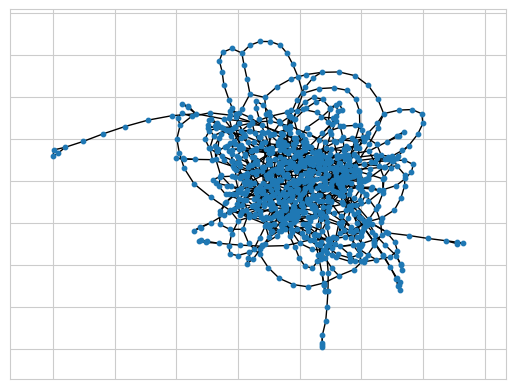

In [70]:
pos = nx.spring_layout(L_core, seed = 1234)
nx.draw_networkx(L_core, with_labels=False, node_size=10, pos=pos)

In [71]:
nx.write_gml(L_core, 'core_graph.gml')

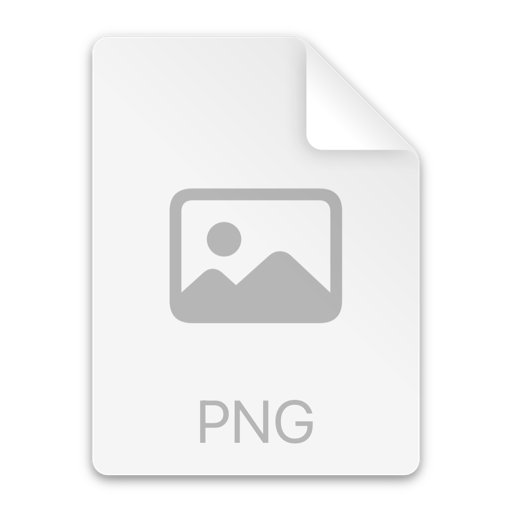

### Core Film Centrality

Below the films featured in the core network are measured for centrality. As they are labelled with id values in the network rather than their names, all centrality measures are calculated and then combined into a single dataframe.

In [72]:
film_d_core = dict(film_proj_core.degree())
film_dc_core = nx.degree_centrality(film_proj_core)
film_cc_core = nx.closeness_centrality(film_proj_core)
film_bc_core = nx.betweenness_centrality(film_proj_core)
film_ec_core = nx.eigenvector_centrality(film_proj_core, max_iter = 10000)
film_pr_core = nx.pagerank(film_proj_core)

film_comparison_core = pd.DataFrame({
    'name': list(film_proj_core.nodes),
    'degree': [film_d_core[n] for n in film_proj_core.nodes()],
    'degree_centrality': [film_dc_core[n] for n in film_proj_core.nodes(

    )],
    'closeness_centrality': [film_cc_core[n] for n in film_proj_core.nodes()],
    'betweenness': [film_bc_core[n] for n in film_proj_core.nodes()],
    'eigenvector': [film_ec_core[n] for n in film_proj_core.nodes()],
    'pagerank': [film_pr_core[n] for n in film_proj_core.nodes()]
})

film = df[['id', 'film_title']]
film_comparison_core = film_comparison_core.merge(film, left_on = 'name', right_on = 'id', how = 'inner').drop(columns = ['name'])
film_comparison_core = film_comparison_core[['id','film_title','degree','degree_centrality','closeness_centrality','betweenness','eigenvector','pagerank']]
film_comparison_core.sort_values('degree', ascending = False).head(15)


,id,film_title,degree,degree_centrality,closeness_centrality,betweenness,eigenvector,pagerank
458,nyt://article/92089f60-c4a0-5741-9013-a4d168cd...,Spider-Man: No Way Home,16,0.030534,0.270242,0.081893,0.278464,0.004747
271,nyt://article/a9c7ca49-b052-58bf-8dc0-da0d6f5f...,Haunted Mansion,15,0.028626,0.245548,0.056516,0.049933,0.005112
41,nyt://article/84f713ec-8c0c-54d7-b8a4-01d58d7d...,Emma,14,0.026718,0.237534,0.042550,0.029506,0.004777
236,nyt://article/d3c8806a-b8b0-598d-92e8-8941513b...,The Woman in the Window,14,0.026718,0.252044,0.058788,0.030880,0.004896
89,nyt://article/eee94e48-7694-5597-9459-ab44cf82...,Drive-Away Dolls,14,0.026718,0.249405,0.045409,0.074298,0.004449
476,nyt://article/ffa6fcbc-1467-5513-976c-3c3ca971...,Poolman,13,0.024809,0.260567,0.066657,0.046390,0.004107
223,nyt://article/e93b2f2a-81ca-5405-9918-61840d7f...,The Hitman,13,0.024809,0.248695,0.028416,0.069672,0.003949
139,nyt://article/6e084a22-9588-54d9-b823-57b007cb...,The Last Thing He Wanted,13,0.024809,0.257367,0.032080,0.193930,0.003859
78,nyt://article/7e7d69db-eb9f-5d18-a304-10bf79ee...,Thor: Love and Thunder,13,0.024809,0.236036,0.035884,0.027507,0.004536
273,nyt://article/6966959e-20d4-5d61-8ebf-b701b61c...,The Croods: A New Age,13,0.024809,0.247754,0.044182,0.048157,0.004629


The list of most central films tends to be larger studio films. Many include several of the most central people, but not that many are large ensemble casts, instead they often have one or two of the most central figures who then work frequently.

### Aggregate Centrality for Analysis

The following code aggregates the centrality measures for central people by film, including the maximum centrality and mean centrality of the poeple to serve as features for analysis.

In [73]:
people_centrality = people_comparison_core.add_prefix('people_')

centrality = edges.merge(people_centrality, left_on = 'person_name', right_on = 'people_name', how = 'inner').drop(columns='people_name')

In [74]:
centrality.columns

Index(['id', 'film_title', 'person_name', 'birth_year', 'position',
       'people_degree', 'people_degree_centrality',
       'people_closeness_centrality', 'people_betweenness',
       'people_eigenvector', 'people_pagerank'],
      dtype='str')

In [75]:
agg_people_centrality = centrality.groupby('id').agg({
    'person_name':['nunique'],
    'people_degree_centrality':['max','mean'],
    'people_closeness_centrality':['max','mean'],
    'people_betweenness':['max','mean'],
    'people_eigenvector':['max','mean'],
    'people_pagerank':['max','mean']
})

agg_people_centrality.columns = [
    '_'.join(col)
    for col in agg_people_centrality.columns
]

agg_people_centrality = agg_people_centrality.reset_index()
agg_people_centrality = agg_people_centrality.rename(columns={'person_name_nunique':'people_count'})

film_comparison_core = film_comparison_core.rename(columns = lambda x: f'film_{x}')



In [76]:
centrality_features = agg_people_centrality.merge(film_comparison_core, left_on = 'id', right_on = 'film_id', how = 'inner').drop(columns = ['film_id']).rename(columns = {'film_film_title':'film_title'})
cols = ['film_title'] + [c for c in centrality_features.columns if c!= 'film_title']
centrality_features = centrality_features[cols]

### Textual Analysis

Next the lead paragraph was cleaned and analyzed with TF-IDF and VADER.

In [77]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [84]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [81]:
combined_features = pd.concat([features], axis = 1)

In [82]:
combined_features = combined_features.merge(centrality_features, on = 'id', how = 'inner')

In [85]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

combined_features['headline_kicker'] = combined_features['headline_kicker'].apply(clean_text)
combined_features['headline_kicker'] = combined_features['headline_kicker'].str.replace(r'' '|streaming|movie review|streaming movie review|documentary lens', '', regex=True)
combined_features['headline_kicker'] = combined_features['headline_kicker'].str.replace(r'critics picks|critics notebook', 'critics pick', regex = True)
combined_features['headline_kicker'] = combined_features['headline_kicker'].str.strip()
combined_features['target_binary'] = (combined_features['headline_kicker'] == 'critics pick').astype(int)

In [86]:
combined_features['target_binary'].value_counts()

target_binary
0    421
1    104
Name: count, dtype: int64

In [87]:
features['clean_text'] = features['lead_paragraph'].apply(clean_text)
features['clean_text'] = features['clean_text'].str.replace(
    'critics pick',
    '',
    regex=False
)

combined_features['clean_text'] = combined_features['lead_paragraph'].apply(clean_text)
combined_features['clean_text'] = combined_features['clean_text'].str.replace(
    'critics pick',
    '',
    regex=False
)

In [139]:
scores = combined_features['clean_text'].fillna('').apply(analyzer.polarity_scores)
vader_features = pd.DataFrame(scores.apply(pd.Series))
combined_features =  pd.concat([combined_features, vader_features], axis = 1)

### Logistic Regression

This initial code uses a logistic regression model on the TF-IDF results from the lead paragraph to see if they can be used to determine whether they are a good predictor of a Critic's Pick.

In [140]:
from scipy.sparse import hstack
from scipy import sparse

In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined_features['clean_text'],
    combined_features['target_binary'],
    test_size = 0.2,
    random_state = 1234,
    stratify = combined_features['target_binary']
)


In [142]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84        84
           1       0.29      0.24      0.26        21

    accuracy                           0.73       105
   macro avg       0.56      0.55      0.55       105
weighted avg       0.71      0.73      0.72       105



Text(50.722222222222214, 0.5, 'Actual')

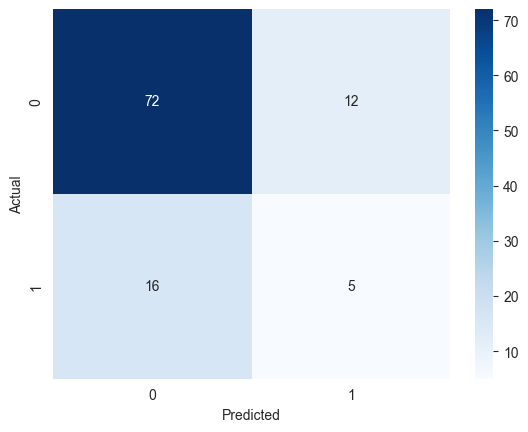

In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

In [144]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_tfidf)[:,1]

roc_auc_score(y_test, y_prob)

0.6842403628117915

The results of logistic regression as applied to the TF-IDF are not particularly strong. The recall for class 1 (the Critic's Pick) is only 24% meaning the model is missing 76% of Critics' Pick, additionally precision for class 1 is only 29%, meaning the model is only picking a Critics' pick correctly that often. Ultimately this model is not selecting Critics' Picks well. The accuracy it appears to have is a result of the fact that the majority of movies are not Critics' Picks, this is an example of a model being accurate by default.

The code below alters the probability threshold, this does not improve  the model, in fact it loses what balance it had. Now, model is predicting far too many things as Critics' Picks. The pendulum has swung the other wya.

              precision    recall  f1-score   support

           0       1.00      0.10      0.17        84
           1       0.22      1.00      0.36        21

    accuracy                           0.28       105
   macro avg       0.61      0.55      0.26       105
weighted avg       0.84      0.28      0.21       105



Text(50.722222222222214, 0.5, 'Actual')

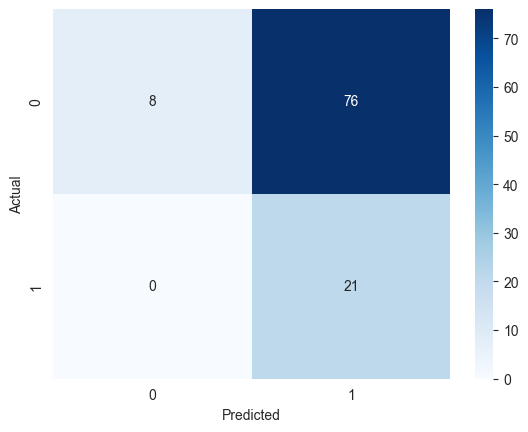

In [145]:
y_pred_03 = (y_prob >= 0.3).astype(int)
cm = confusion_matrix(y_test, y_pred_03)

print(classification_report(y_test, y_pred_03))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

The top most important words are listed below.

In [146]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_features = pd.DataFrame({
    'word': feature_names,
    'weight': coefficients
}).sort_values('weight', ascending=False)

top_features.head(15)

,word,weight
309,heart,1.183548
243,filmmaker,1.143949
219,far,0.925040
287,great,0.898281
769,set,0.891943
260,french,0.857933
263,friend,0.819062
795,small,0.809540
48,beautiful,0.803056
56,big,0.797690


With the generally poor performance of the model using TF-IDF, the VADER analysis was considered as an addition to the TF-IDF data.

In [147]:
def vader_features(series):
    scores = series.fillna('').apply(lambda x: analyzer.polarity_scores(x))
    return pd.DataFrame(scores.tolist())

X_train_vader = vader_features(X_train)
X_test_vader = vader_features(X_test)

In [148]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

X_train_tfidf_vader = hstack([X_train_tfidf, X_train_vader])
X_test_tfidf_vader = hstack([X_test_tfidf, X_test_vader])

              precision    recall  f1-score   support

           0       0.84      0.83      0.84        84
           1       0.36      0.38      0.37        21

    accuracy                           0.74       105
   macro avg       0.60      0.61      0.61       105
weighted avg       0.75      0.74      0.75       105



Text(50.722222222222214, 0.5, 'Actual')

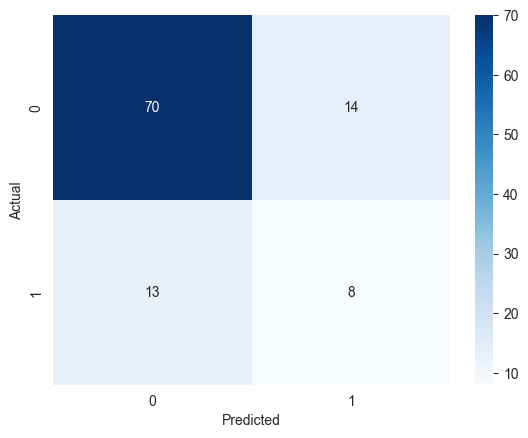

In [149]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf_vader, y_train)


y_pred = model.predict(X_test_tfidf_vader)
cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

The model results above are far more balanced than TF-IDF alone.  False Positives and False Negatives are occurring at identical rates. That being said recall is still only 38% for class 1 and precisions is 36%.

### Considering Network Features


In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined_features[['people_count', 'people_degree_centrality_max', 'people_pagerank_max', 'people_eigenvector_max', 'film_pagerank']],
    combined_features['target_binary'],
    test_size=0.2,
    random_state=1234,
    stratify=combined_features['target_binary']
)

              precision    recall  f1-score   support

           0       0.81      0.67      0.73        84
           1       0.22      0.38      0.28        21

    accuracy                           0.61       105
   macro avg       0.52      0.52      0.51       105
weighted avg       0.69      0.61      0.64       105



Text(50.722222222222214, 0.5, 'Actual')

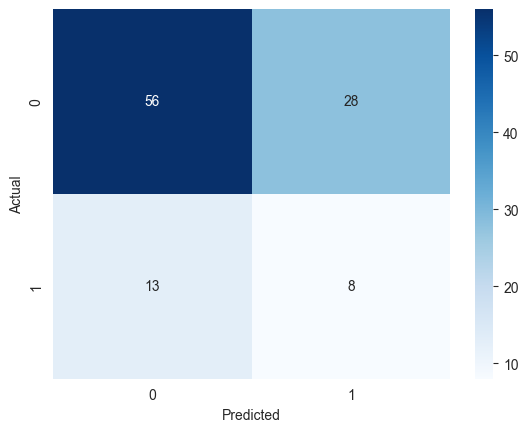

In [151]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

In [152]:
y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.5334467120181406

None of the methods thus far have been particularly good at predicting the Critics' Picks. With this in mind, the single feature, word count was attempted. The results were surprising.

0.8021541950113379
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        84
           1       0.45      0.71      0.56        21

    accuracy                           0.77       105
   macro avg       0.69      0.75      0.70       105
weighted avg       0.82      0.77      0.79       105



Text(50.722222222222214, 0.5, 'Actual')

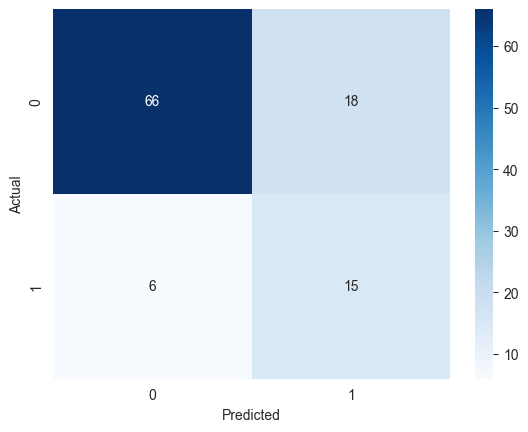

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined_features[['word_count']],
    combined_features['target_binary'],
    test_size=0.2,
    random_state=1234,
    stratify=combined_features['target_binary']
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
y_prob = model.predict_proba(X_test)[:,1]


print(roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

The ROC-AUC result of 0.80 indicates that, given a randomly selected Critic's Pick and non-Critic's Pick, 80% of the time the model would predict a higher score for the Critics' Pick.

The recall is the best so far at 71% and precision is 45% for class 1. This is the most effective model observed so far.

As a sanity check, the code below runs the same model but shuffles the y labels. Were the results above not related to signal, there would not be significant change in the results. However, as observed below the model performance drops significantly on all parameters. As it turns out word count is the best predictor observed.

This is likely a results of a critic (and their editor) using similar counts of words for lead paragraphs for Critics' Picks.

0.19784580498866214
              precision    recall  f1-score   support

           0       0.61      0.27      0.38        84
           1       0.09      0.29      0.14        21

    accuracy                           0.28       105
   macro avg       0.35      0.28      0.26       105
weighted avg       0.50      0.28      0.33       105



Text(50.722222222222214, 0.5, 'Actual')

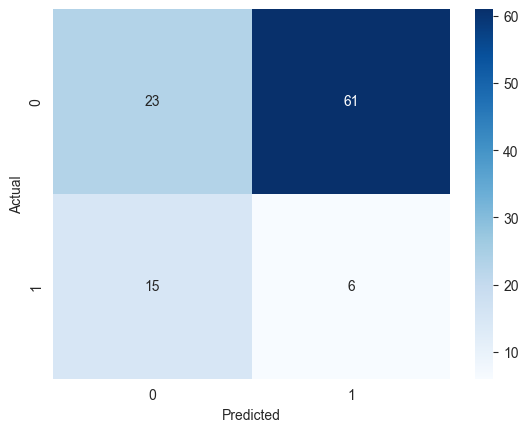

In [154]:
from sklearn.utils import shuffle

y_shuffled = shuffle(y_train, random_state=1234)

model.fit(X_train, y_shuffled)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
y_prob = model.predict_proba(X_test)[:, 1]

print(roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

### Recursive Feature Elimination

In order to determine if there is a better selection of metadata and other features than just word count, below is a use of recursive feature elimination (RFE) in order to determine the best collection of features for logistic regression.

First features are selected, thne the RFE is run.

In [156]:
recursive_features = combined_features[['id','clean_text','word_count','neg','neu','pos','compound','people_count','people_degree_centrality_max', 'people_degree_centrality_mean',
       'people_closeness_centrality_max', 'people_closeness_centrality_mean',
       'people_betweenness_max', 'people_betweenness_mean',
       'people_eigenvector_max', 'people_eigenvector_mean',
       'people_pagerank_max', 'people_pagerank_mean', 'film_degree',
       'film_degree_centrality', 'film_closeness_centrality',
       'film_betweenness', 'film_eigenvector', 'film_pagerank',
       'target_binary']]

In [157]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

features =  [c for c in recursive_features.columns if c not in ['id', 'clean_text','target_binary']]

feat_count = len(features)
thresholds = [0.3, 0.4, 0.5, 0.6]

df_for_feat_selec = []

X_train, X_test, y_train, y_test = train_test_split(
    recursive_features[features],
    recursive_features['target_binary'],
    test_size=0.2,
    random_state=1234,
    stratify=recursive_features['target_binary']
)

for num in range(1, feat_count + 1):

    base_model = LogisticRegression(max_iter=10000, class_weight='balanced')

    selector = RFE(base_model, n_features_to_select=num)

    X_train_rfe = selector.fit_transform(X_train, y_train)
    X_test_rfe = selector.transform(X_test)

    logreg = LogisticRegression(max_iter=10000, class_weight='balanced')
    logreg.fit(X_train_rfe, y_train)

    log_probs = logreg.predict_proba(X_test_rfe)[:, 1]

    for threshold in thresholds:

        log_y_pre = (log_probs >= threshold).astype(int)

        cm = confusion_matrix(y_test, log_y_pre)

        tn, fp, fn, tp = cm.ravel()

        df_for_feat_selec.append({
            'features': num,
            'threshold': threshold,
            'accuracy': accuracy_score(y_test, log_y_pre),

            'precision': precision_score(y_test, log_y_pre, zero_division=0),
            'recall': recall_score(y_test, log_y_pre, zero_division=0),
            'f1': f1_score(y_test, log_y_pre, zero_division=0),

            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn,

            'mis_error': (fp + fn) / (fp + fn + tp + tn)
        })

df_for_feat_selec = pd.DataFrame(df_for_feat_selec)

df_for_feat_selec = df_for_feat_selec.sort_values(
    by='mis_error',
    ascending=True
)

df_for_feat_selec.head(20)

,features,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,mis_error
51,13,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
31,8,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
35,9,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
39,10,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
43,11,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
47,12,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
55,14,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
59,15,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
63,16,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476
67,17,0.6,0.809524,1.0,0.047619,0.090909,1,0,20,84,0.190476


The results above indicate that between 19 and 22 features yield the best overall results, improved over the single feature model. In this model at a 0.6 probability threshold, the recall is 71%, and precision is 65% with an overall 86.7% accuracy. It also has realtively balanced false positive and false negatives, and miscalculation error of 13%.

This raises the question, could the critic themselves by a feature for predicting Critics' Pick?

Below is a list of critics and the number of reviews they have in the dataset.

In [158]:
combined_features['byline_original'].value_counts()

byline_original
By Manohla Dargis           96
By Jeannette Catsoulis      63
By A.O. Scott               51
By Amy Nicholson            46
By Glenn Kenny              45
By Ben Kenigsberg           35
By Alissa Wilkinson         28
By Natalia Winkelman        20
By Beatrice Loayza          16
By Calum Marsh              12
By Maya Phillips            11
By Teo Bugbee               10
By Nicolas Rapold            9
By Brandon Yu                9
By Elisabeth Vincentelli     8
By Lisa Kennedy              7
By Claire Shaffer            7
By Robert Daniels            6
By Lena Wilson               6
By Wesley Morris             6
By Devika Girish             4
By Beandrea July             4
By Jessica Kiang             3
By Kristen Yoonsoo Kim       3
By Concepción de León        3
By Jason Zinoman             3
By Helen T. Verongos         2
By Lovia Gyarkye             2
By Kyle Turner               2
By Austin Considine          2
By Jennifer Szalai           1
By Aisha Harris        

To include them OneHotEncoder was used to encode them in a sparse matrix, then RFE was run again.

In [159]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoded = encoder.fit_transform(combined_features[['byline_original']])
encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=encoder.get_feature_names_out(['byline_original'])
)
encoded_features = pd.concat([recursive_features, encoded_df], axis=1)

In [160]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

features =  [c for c in encoded_features.columns if c not in ['id', 'clean_text','target_binary']]

feat_count = len(features)
thresholds = [0.3, 0.4, 0.5, 0.6]

df_for_feat_selec = []

X_train, X_test, y_train, y_test = train_test_split(
    encoded_features[features],
    encoded_features['target_binary'],
    test_size=0.2,
    random_state=1234,
    stratify=encoded_features['target_binary']
)

for num in range(1, feat_count + 1):

    base_model = LogisticRegression(max_iter=10000, class_weight='balanced')

    selector = RFE(base_model, n_features_to_select=num)

    X_train_rfe = selector.fit_transform(X_train, y_train)
    X_test_rfe = selector.transform(X_test)

    logreg = LogisticRegression(max_iter=10000, class_weight='balanced')
    logreg.fit(X_train_rfe, y_train)

    log_probs = logreg.predict_proba(X_test_rfe)[:, 1]

    for threshold in thresholds:

        log_y_pre = (log_probs >= threshold).astype(int)

        cm = confusion_matrix(y_test, log_y_pre)

        tn, fp, fn, tp = cm.ravel()

        df_for_feat_selec.append({
            'features': num,
            'threshold': threshold,
            'accuracy': accuracy_score(y_test, log_y_pre),

            'precision': precision_score(y_test, log_y_pre, zero_division=0),
            'recall': recall_score(y_test, log_y_pre, zero_division=0),
            'f1': f1_score(y_test, log_y_pre, zero_division=0),

            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn,

            'mis_error': (fp + fn) / (fp + fn + tp + tn)
        })

df_for_feat_selec = pd.DataFrame(df_for_feat_selec)

df_for_feat_selec = df_for_feat_selec.sort_values(
    by='mis_error',
    ascending=True
)

df_for_feat_selec.head(20)

,features,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,mis_error
247,62,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524
243,61,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524
2,1,0.5,0.790476,0.400000,0.095238,0.153846,2,3,19,81,0.209524
3,1,0.6,0.790476,0.400000,0.095238,0.153846,2,3,19,81,0.209524
239,60,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524
235,59,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524
231,58,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524
227,57,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524
223,56,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524
219,55,0.6,0.790476,0.482759,0.666667,0.560000,14,15,7,69,0.209524


Ultimately the model performs slightly worse than when the Critic was not considered. However, this may be a result of RFE not handling the sparse matrix created by the OneHotEncoder well.

The logistic regression was run again with a for loop but without RFE below.

In [161]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

features = [c for c in encoded_features.columns
            if c not in ['id', 'clean_text','target_binary']]

X = encoded_features[features]
y = encoded_features['target_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1234,
    stratify=y
)

model = LogisticRegression(max_iter=10000, class_weight='balanced')
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

thresholds = [0.2,0.3, 0.4, 0.5, 0.6,0.7]

results = []

for t in thresholds:
    y_pred = (probs >= t).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "mis_error": (fp + fn) / (fp + fn + tp + tn)
    })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df

,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,mis_error
3,0.5,0.828571,0.542857,0.904762,0.678571,19,16,2,68,0.171429
4,0.6,0.857143,0.636364,0.666667,0.651163,14,8,7,76,0.142857
2,0.4,0.742857,0.434783,0.952381,0.597015,20,26,1,58,0.257143
1,0.3,0.666667,0.370370,0.952381,0.533333,20,34,1,50,0.333333
5,0.7,0.828571,0.615385,0.380952,0.470588,8,5,13,79,0.171429
0,0.2,0.533333,0.294118,0.952381,0.449438,20,48,1,36,0.466667


The results above are compelling. For the top result, miscalculation error has increased by about 5% compared to the first RFE (without critics included as a feature), the recall is above 90% while the F1 is 66.7% which is a notable increase in recall and only a small decrease in F1. Accuracy is nearly 82%. The false negative rate is very low, so the model is missing very few Critics' Picks. It has 17 false positives, so it is assigning Critics' Picks at higher rates than other models but this version is ensuring that very few Critics' Picks are missed.

The ROC-AUC score is also 88% (as seen below); this is a very promising return.

Ultimately, the question is of priorities and how to balance them, this will dictate which model is most effective for the needs. Is it more important to not miss any Critics' Picks, even if it means more false positives? Or should false positives be minimized? This will help dicatate the model that should be used.

In [162]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

roc_auc = roc_auc_score(y_test, probs)
print(roc_auc)

0.8866213151927438


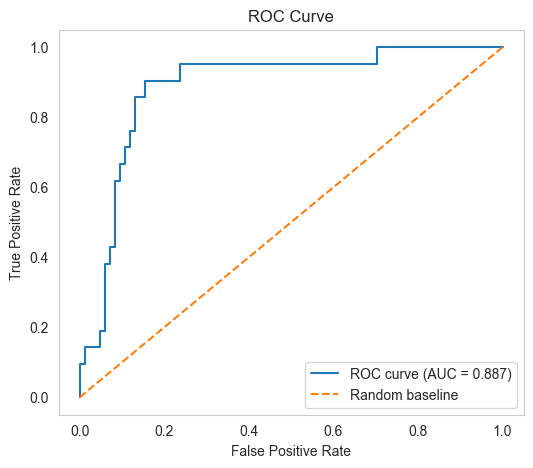

In [163]:
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

Finally, would the reintroduction of the TF-IDF features improve the model? This is explored below.

In [169]:
encoded_features = encoded_features.loc[:, ~encoded_features.columns.duplicated()]

In [170]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


numeric_features = [c for c in encoded_features.columns
                    if c not in ['id', 'target_binary', 'clean_text']]

preprocess = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, ngram_range=(1,2)), 'clean_text'),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline([
    ('features', preprocess),
    ('clf', LogisticRegression(max_iter=10000, class_weight='balanced'))
])

X = encoded_features
y = encoded_features['target_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1234,
    stratify=y
)

model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for t in thresholds:
    preds = (probs >= t).astype(int)

    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "mis_error": (fp + fn) / (fp + fn + tp + tn)
    })

pd.DataFrame(results).sort_values("f1", ascending=False)

,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,mis_error
0,0.2,0.828571,0.615385,0.380952,0.470588,20,41,1,43,0.400000
1,0.3,0.828571,0.615385,0.380952,0.470588,20,29,1,55,0.285714
2,0.4,0.828571,0.615385,0.380952,0.470588,19,17,2,67,0.180952
3,0.5,0.828571,0.615385,0.380952,0.470588,16,10,5,74,0.142857
4,0.6,0.828571,0.615385,0.380952,0.470588,10,7,11,77,0.171429
5,0.7,0.828571,0.615385,0.380952,0.470588,4,4,17,80,0.200000


The results, are not an improvement over the previous model. The TF-IDF analysis has not proven to be useful in predicting whether a film receives a Critics' Pick.

### SVM

Another model that might prove a useful predictor is Support Vector Machines. Could it prove more useful at using the TF-IDF data as a predictor?

In [171]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

In [172]:
X = encoded_features['clean_text']
y = encoded_features['target_binary']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1234,
    stratify=y
)

svm = LinearSVC(class_weight='balanced')

model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('svm', CalibratedClassifierCV(svm))
])

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for t in thresholds:
    preds = (probs >= t).astype(int)

    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "mis_error": (fp + fn) / (tp + tn + fp + fn)
    })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df

,threshold,accuracy,precision,recall,f1,tp,fp,fn,tn,mis_error
0,0.2,0.628571,0.312500,0.714286,0.434783,15,33,6,51,0.371429
1,0.3,0.780952,0.428571,0.285714,0.342857,6,8,15,76,0.219048
2,0.4,0.809524,0.600000,0.142857,0.230769,3,2,18,82,0.190476
3,0.5,0.800000,0.000000,0.000000,0.000000,0,0,21,84,0.200000
4,0.6,0.800000,0.000000,0.000000,0.000000,0,0,21,84,0.200000
5,0.7,0.800000,0.000000,0.000000,0.000000,0,0,21,84,0.200000


In the end, at least with this set of features, the SVM does not provide improved prediction abilities for identfying a Critics' Pick, and the model completely collapses at probability thresholds above 0.4.